In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
orth_data = np.load('eval_loss_orth.npz')
td_data = np.load('eval_loss_td.npz')
classic_data = np.load('eval_loss_classic.npz')

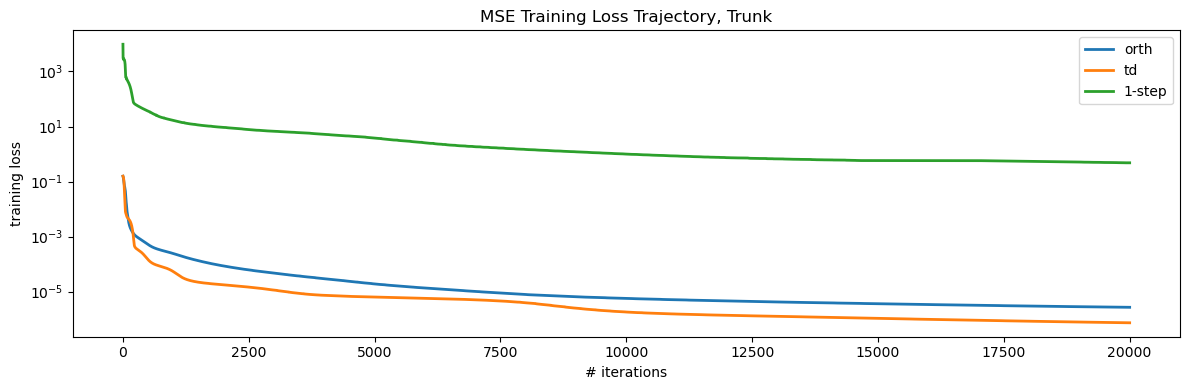

In [4]:
plt.figure(figsize = (12,4))
plt.semilogy(orth_data['train_minloss'], linewidth = 2, label = 'orth')
plt.semilogy(td_data['train_minloss'], linewidth =2, label = 'td')
plt.semilogy(classic_data['train_minloss'], linewidth = 2, label = '1-step')
plt.xlabel('# iterations')
plt.ylabel('training loss')
plt.title("MSE Training Loss Trajectory, Trunk")
plt.legend()
plt.tight_layout()
# plt.suptitle(title_str + '\n')
plt.savefig("deeponet_compare_training.png")
plt.show()

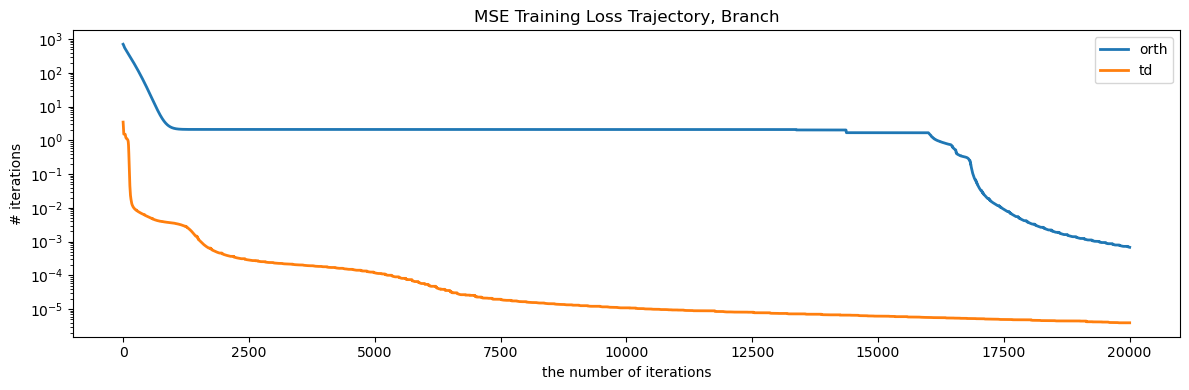

In [5]:
plt.figure(figsize = (12,4))
plt.semilogy(orth_data['branch_minloss'], linewidth = 2, label = 'orth')
plt.semilogy(td_data['branch_minloss'], linewidth =2, label = 'td')
plt.xlabel('the number of iterations')
plt.ylabel('# iterations')
plt.title("MSE Training Loss Trajectory, Branch")
plt.legend()
plt.tight_layout()
# plt.suptitle(title_str + '\n')
plt.savefig("deeponet_compare_training_branch.png")
plt.show()

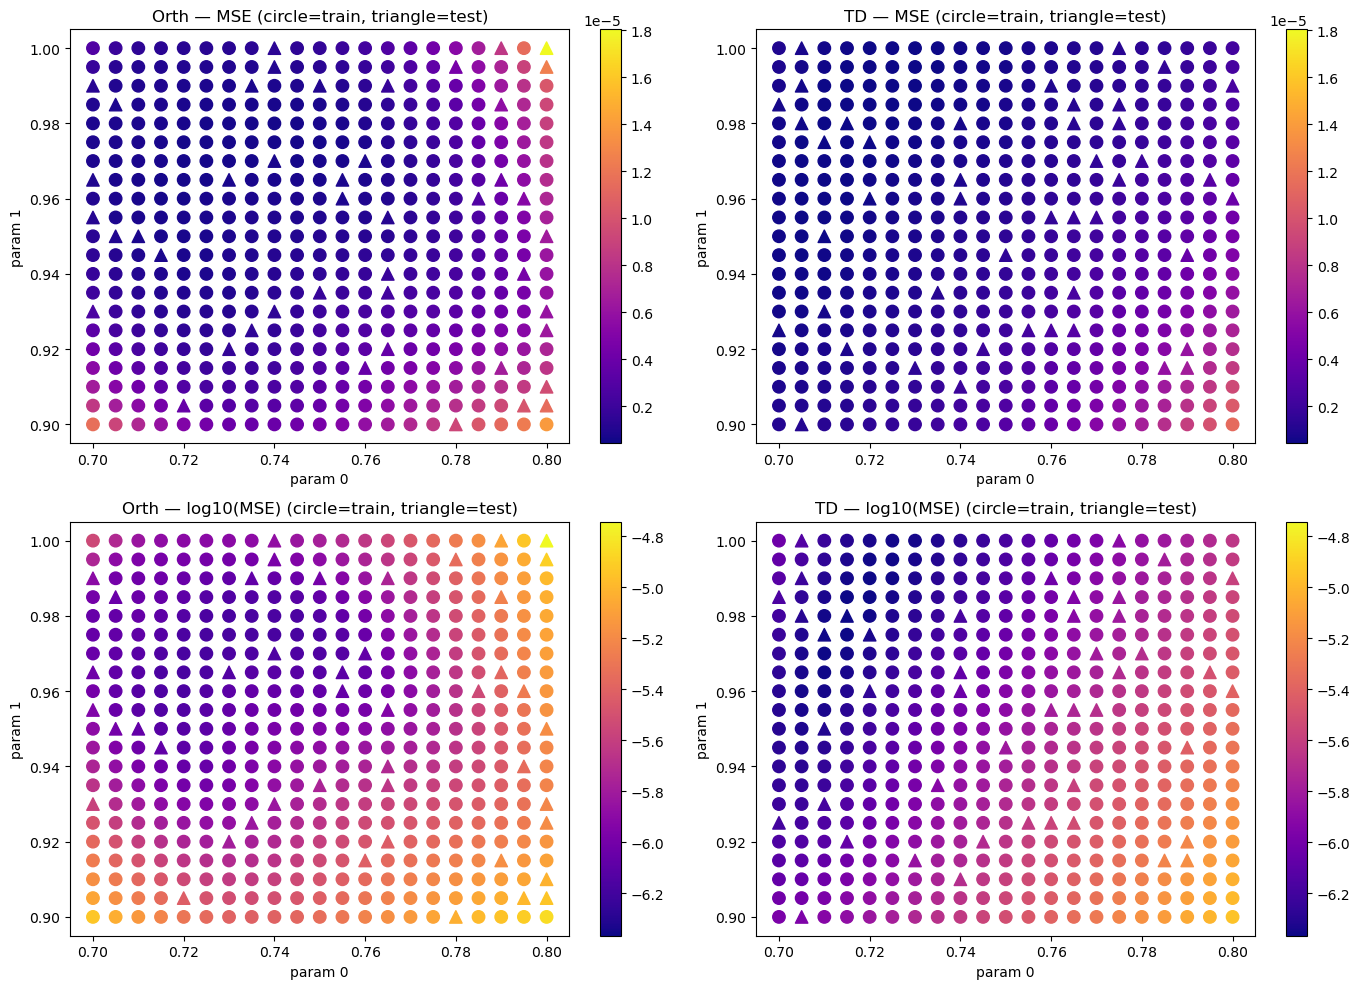

In [12]:
orth_data = np.load('all_mse_orth.npz')
td_data   = np.load('all_mse_td.npz')

models = {
    'Orth': orth_data,
    'TD':   td_data,
}

all_mse_combined = np.concatenate([d['train_loss'] for d in models.values()] +
                                   [d['test_loss']  for d in models.values()])
vmin,     vmax     = all_mse_combined.min(),        all_mse_combined.max()
log_vmin, log_vmax = np.log10(vmin),                np.log10(vmax)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (name, data) in enumerate(models.items()):
    train_params = data['train_params']
    test_params  = data['test_params']
    train_mse    = data['train_loss']
    test_mse     = data['test_loss']

    ax = axes[0, col]
    sc = ax.scatter(train_params[:, 0], train_params[:, 1], c=train_mse, cmap='plasma', s=80, vmin=vmin, vmax=vmax)
    ax.scatter(test_params[:, 0],  test_params[:, 1],  c=test_mse,  cmap='plasma', s=80, vmin=vmin, vmax=vmax, marker='^')
    fig.colorbar(sc, ax=ax)
    ax.set_title(f"{name} — MSE (circle=train, triangle=test)")
    ax.set_xlabel("param 0")
    ax.set_ylabel("param 1")

    ax = axes[1, col]
    sc = ax.scatter(train_params[:, 0], train_params[:, 1], c=np.log10(train_mse), cmap='plasma', s=80, vmin=log_vmin, vmax=log_vmax)
    ax.scatter(test_params[:, 0],  test_params[:, 1],  c=np.log10(test_mse),  cmap='plasma', s=80, vmin=log_vmin, vmax=log_vmax, marker='^')
    fig.colorbar(sc, ax=ax)
    ax.set_title(f"{name} — log10(MSE) (circle=train, triangle=test)")
    ax.set_xlabel("param 0")
    ax.set_ylabel("param 1")

plt.tight_layout()
plt.show()

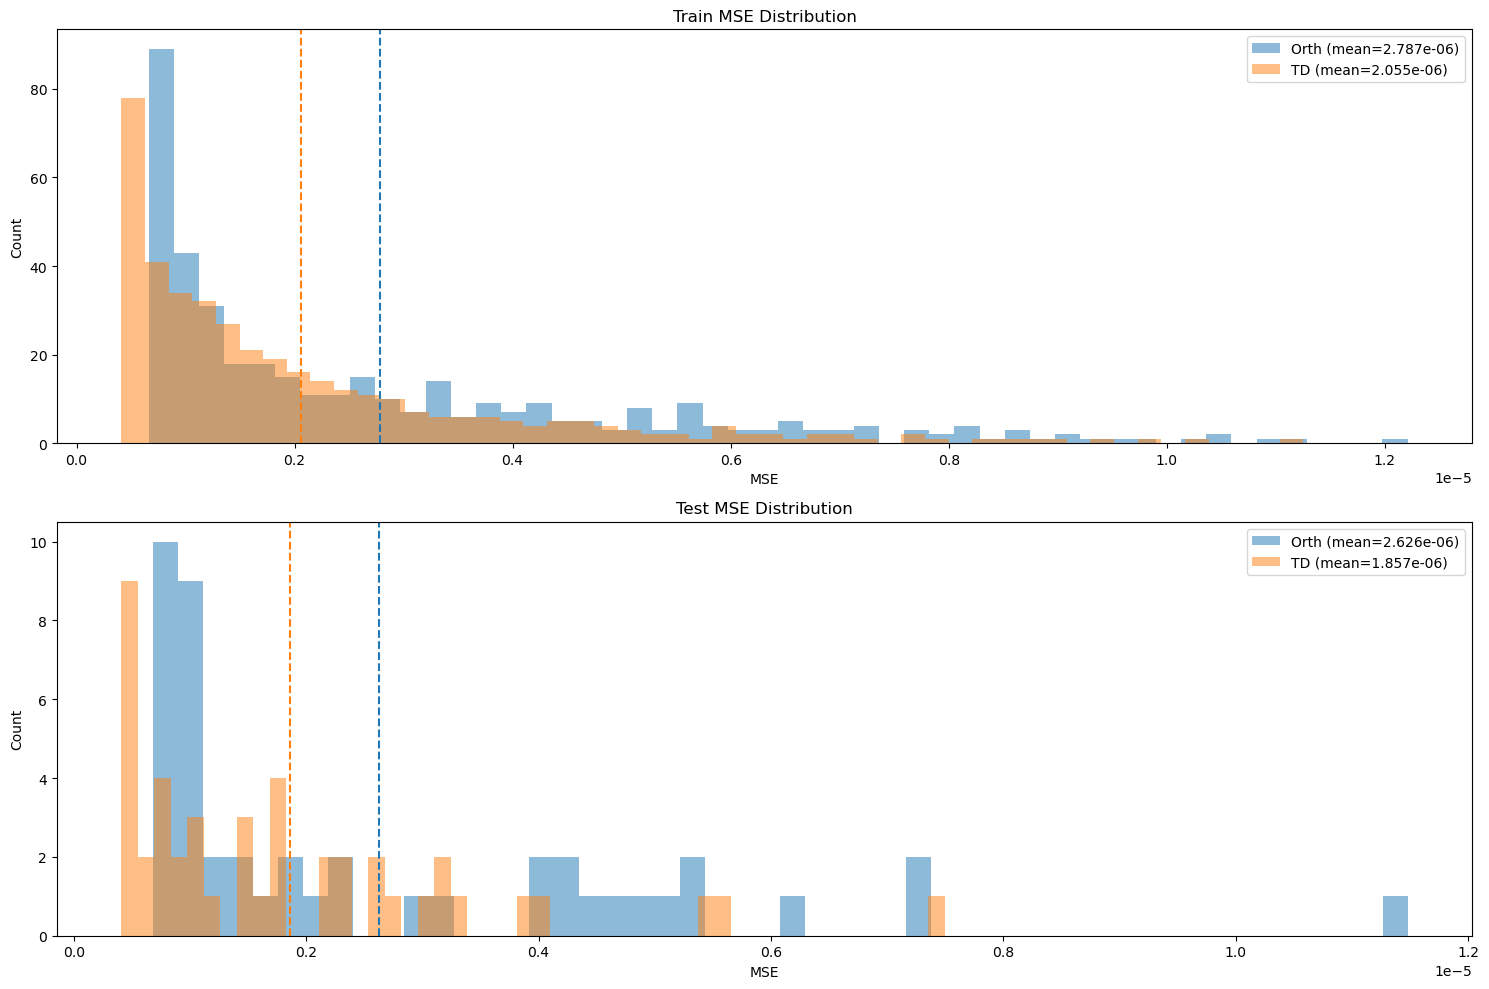

In [18]:
# %%
models_all = {
    'Orth':    np.load('all_mse_orth.npz'),
    'TD':      np.load('all_mse_td.npz'),
    #'Classic': np.load('all_mse_classic.npz'),
}

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
bins = 50

for i, (name, data) in enumerate(models_all.items()):
    train_mse = data['train_loss']
    test_mse  = data['test_loss']
    axes[0].hist(train_mse, bins=bins, alpha=0.5, color=f'C{i}', label=f"{name} (mean={train_mse.mean():.3e})")
    axes[0].axvline(train_mse.mean(), linestyle='--', linewidth=1.5, color=f'C{i}')
    axes[1].hist(test_mse,  bins=bins, alpha=0.5, color=f'C{i}', label=f"{name} (mean={test_mse.mean():.3e})")
    axes[1].axvline(test_mse.mean(),  linestyle='--', linewidth=1.5, color=f'C{i}')

for ax, title in zip(axes, ["Train MSE Distribution", "Test MSE Distribution"]):
    ax.set_xlabel("MSE")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig("deeponet_compare_mse_hist.png")
plt.show()